# Assembly history modulates vertical root distribution in a grassland experiment — reproduction

Reproduction of the statistical analyses of **Alonso-Crespo et al. (2021), *Assembly history modulates vertical root distribution in a grassland experiment*** (bioRxiv, DOI [10.1101/2021.08.24.457510](https://doi.org/10.1101/2021.08.24.457510)).

**Scope.** Two analyses from the authors' shared data and annotated R code (repo [`BenjaminDelory/PE_Rhizobox_2017_data`](https://github.com/BenjaminDelory/PE_Rhizobox_2017_data), pinned commit `438f028f`):
1. **Root-biomass depth profile** — a zero-altered gamma (hurdle) GLMM across six 10-cm soil layers by priority-effect treatment (paper Figure 4 analog).
2. **MRD temporal evolution** — a linear mixed model of image-derived mean rooting depth vs. days after sowing (paper Figure 5 analog).

**Not included:** RootPainter CNN training/re-segmentation (raw rhizobox photographs are not public; only precomputed `results.csv` MRD values are shared), shoot-biomass species-level models, MaxRD LMM, and bootstrap effect-size contrasts.

**Status: executed CPU demonstration** — validated top-to-bottom in a fresh Colab CPU runtime (see final report). One-example/data-level scope; this does not verify dataset-level published accuracy.

本ノートブックは上記論文の統計解析（土壌層別根バイオマスのハードルGLMM、画像由来平均 rooting depth の線形混合モデル）を、著者公開データとピン留めした R コード（commit `438f028f`）から再現します。RootPainter CNN の再学習・再セグメンテーション（元画像非公開のため不可）と種別シュート解析は対象外です。CPU ランタイムで動作します。

## Runtime selection

**Select Runtime → Change runtime type → CPU** (default). The models are small (`lme4`/`MASS` GLMM/LMM on ≤665 rows); no GPU, no CNN weights, and under 1 GiB RAM are needed. Total runtime is a few minutes, dominated by possible R package installation.

ランタイムは CPU で十分です（GPU 不要・数百行の統計モデルのみ）。

### Check the R environment

The analysis runs the authors' R code with `Rscript`. This cell verifies that `Rscript` exists and that the required packages `MASS` (hurdle `glmmPQL`) and `lme4` (LMM) are available, installing them from CRAN only if missing.

まず `Rscript` と必要パッケージ（`MASS`, `lme4`）の有無を確認し、無い場合のみ CRAN からインストールします。

In [ ]:
import subprocess, sys

r = subprocess.run(["bash", "-lc", "command -v Rscript && Rscript --version"],
                   capture_output=True, text=True, timeout=120)
print(r.stdout, r.stderr)
assert r.returncode == 0, "Rscript not found on this runtime"

check = subprocess.run(
    ["Rscript", "-e",
     'ip <- rownames(installed.packages()); '
     'cat("MASS:", "MASS" %in% ip, " lme4:", "lme4" %in% ip, "\n")'],
    capture_output=True, text=True, timeout=300)
print(check.stdout, check.stderr)
have_both = check.stdout.count("TRUE") == 2

if not have_both:
    print("Installing missing R packages from CRAN (this can take several minutes)...")
    inst = subprocess.run(
        ["Rscript", "-e",
         'install.packages(c("MASS", "lme4"), repos="https://cloud.r-project.org")'],
        capture_output=True, text=True, timeout=2400)
    print(inst.stdout[-3000:], inst.stderr[-3000:])
    assert inst.returncode == 0, "R package installation failed"
else:
    print("Required packages already present.")

/usr/bin/Rscript
Rscript (R) version 4.6.1 (2026-06-24)
 


MASS: TRUE  lme4: FALSE 
 
Installing missing R packages from CRAN (this can take several minutes)...


ointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3   -c external.cpp -o external.o
x86_64-linux-gnu-g++ -std=gnu++20 -I"/usr/share/R/include" -DNDEBUG  -I'/usr/lib/R/site-library/Matrix/include' -I'/usr/lib/R/site-library/Rcpp/include' -I'/usr/local/lib/R/site-library/RcppEigen/include'    -DNDEBUG -DEIGEN_DONT_VECTORIZE -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3   -c glmFamily.cpp -o glmFamily.o
x86_64-linux-gnu-g++ -std=gnu++20 -I"/usr/share/R/inc

## Data acquisition (pinned commit)

All four input files are downloaded **inside this notebook** from the authors' repository at the exact pinned commit [`438f028f`](https://github.com/BenjaminDelory/PE_Rhizobox_2017_data/tree/438f028fb2e1713a9e253be9e07df0833b491f47) (`Data/` directory, raw URLs):

| File | Bytes | Git blob SHA-1 | Role |
|---|---|---|---|
| `Data_root_biomass_RZ_PE_2017.txt` | 6,050 | `d7822cef…` | root dry weight per 10-cm layer × rhizobox |
| `Date_TimePoint.txt` | 603 | `6d64b5c5…` | camera date → days since first sowing |
| `Image_RZ.txt` | 212 | `3ba8501a…` | image filename → rhizobox ID |
| `results.csv` | 39,346 | `ecffb475…` | per-image MRD/maxRD from RootPainter segmentations |

Each file's size and **git blob SHA-1** are verified against the pinned tree before use.

データは著者リポジトリの指定コミットからノートブック内でダウンロードし、サイズと git blob SHA-1 を検証します。

In [ ]:
import hashlib, urllib.request, pathlib

COMMIT = "438f028fb2e1713a9e253be9e07df0833b491f47"
RAW = "https://raw.githubusercontent.com/BenjaminDelory/PE_Rhizobox_2017_data/438f028fb2e1713a9e253be9e07df0833b491f47/Data"
EXPECTED = {  # (bytes, git blob sha1) from the pinned commit's tree
    "Data_root_biomass_RZ_PE_2017.txt": (6050, "d7822cefa35f41b144a87c0184f6029e9726bca9"),
    "Date_TimePoint.txt":               (603,  "6d64b5c530d61a40c6549c12308c76b759c7ef3a"),
    "Image_RZ.txt":                     (212,  "3ba8501a20512813d61680f527d682062144d2bf"),
    "results.csv":                      (39346, "ecffb475ca8644d725ef7a714f0870cc162d8018"),
}

def blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

for name, (size, sha) in EXPECTED.items():
    dst = pathlib.Path("/content") / name
    if not dst.exists():
        urllib.request.urlretrieve(f"{RAW}/{name}", dst)  # nosec - pinned public URL
    data = dst.read_bytes()
    assert len(data) == size, f"{name}: size {len(data)} != {size}"
    got = blob_sha1(data)
    assert got == sha, f"{name}: blob sha {got} != {sha}"
    print(f"OK  {name}: {len(data)} bytes, blob {got}")

OK  Data_root_biomass_RZ_PE_2017.txt: 6050 bytes, blob d7822cefa35f41b144a87c0184f6029e9726bca9
OK  Date_TimePoint.txt: 603 bytes, blob 6d64b5c530d61a40c6549c12308c76b759c7ef3a
OK  Image_RZ.txt: 212 bytes, blob 3ba8501a20512813d61680f527d682062144d2bf


OK  results.csv: 39346 bytes, blob ecffb475ca8644d725ef7a714f0870cc162d8018


## Input preview

Before any modelling, this cell shows the actual downloaded tables (shape, columns, units) and a raw-data view of the MRD time series per treatment — the direct input to analysis 2. Note that `results.csv` records MRD in cm **below the surface origin (negative values)**, as produced by the authors' Python script; magnitudes are the meaningful depth.

解析前に実データの中身（列・単位・行数）と、処理前の MRD 時系列を確認します。`results.csv` の MRD は地表面原点で負の値（著者の Python コードの出力仕様）です。

Root biomass table: (186, 6) | columns: ['Rz', 'Treatment', 'Replicate', 'Layer', 'maxDepth', 'RDW']
 Rz Treatment  Replicate    Layer  maxDepth      RDW
  3     Sync1          1  0-10 cm        10 0.153202
  3     Sync1          1 10-20 cm        20 0.055916
  3     Sync1          1 20-30 cm        30 0.022280
  3     Sync1          1 30-40 cm        40 0.010505
  3     Sync1          1 40-50 cm        50 0.005288
  3     Sync1          1 50-60 cm        60 0.001773
 43     Sync1          2  0-10 cm        10 0.116085

RootPainter results.csv: (665, 3) | columns: ['image', 'mrd', 'maxrd']
                 image       mrd     maxrd
2017-08-16-RZ-0001.png -2.445048 -2.520738
2017-08-16-RZ-0002.png  0.000000  0.000000
2017-08-16-RZ-0003.png  0.000000  0.000000


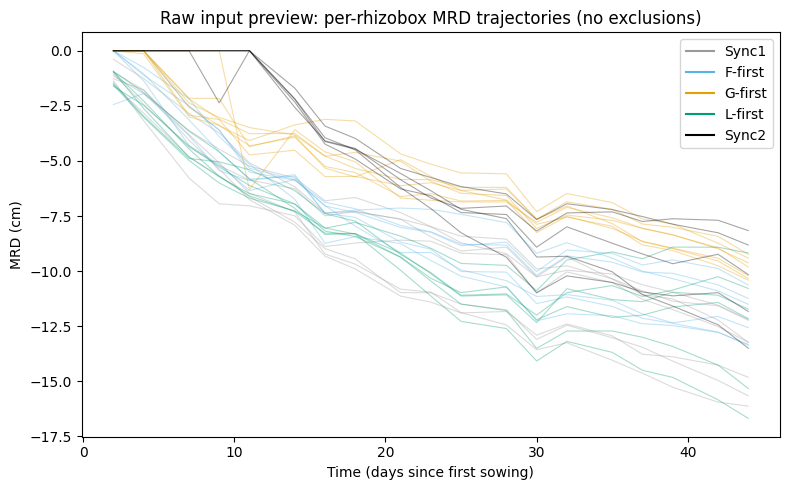


Rows per treatment (raw): {'G-first': 133, 'Sync1': 133, 'F-first': 114, 'L-first': 114, 'Sync2': 95}


In [ ]:
import pandas as pd, matplotlib.pyplot as plt

root_df = pd.read_csv("/content/Data_root_biomass_RZ_PE_2017.txt", sep="\t")
res_df  = pd.read_csv("/content/results.csv")
print("Root biomass table:", root_df.shape, "| columns:", list(root_df.columns))
print(root_df.head(7).to_string(index=False))
print("\nRootPainter results.csv:", res_df.shape, "| columns:", list(res_df.columns))
print(res_df.head(3).to_string(index=False))

# Map image -> rhizobox / day to preview raw MRD trajectories (before author exclusions)
id_df  = pd.read_csv("/content/Image_RZ.txt", sep="\t")
time_df = pd.read_csv("/content/Date_TimePoint.txt", sep="\t")
parts = res_df["image"].str.split("-", expand=True)
res_df["imageID"] = pd.to_numeric(parts[4].str.replace(".png", "", regex=False))
res_df["Date"] = parts[0] + "-" + parts[1] + "-" + parts[2]
res_df["Rz"] = res_df["imageID"].map(id_df.set_index("Image")["RZ"])
res_df["Time"] = res_df["Date"].map(time_df.set_index("Date")["Day"])

TREAT = {rz: t for rz, t in zip(root_df["Rz"], root_df["Treatment"])}
res_df["Treatment"] = res_df["Rz"].map(TREAT)
treat_order = ["Sync1", "F-first", "G-first", "L-first", "Sync2"]
colors = ["#999999", "#56B4E9", "#E69F00", "#009E73", "black"]

fig, ax = plt.subplots(figsize=(8, 5))
for tr, c in zip(treat_order, colors):
    sub = res_df[res_df["Treatment"] == tr]
    for rz, g in sub.groupby("Rz"):
        ax.plot(g["Time"], g["mrd"], color=c, alpha=0.35, lw=0.8)
    ax.plot([], [], color=c, label=tr)
ax.set_xlabel("Time (days since first sowing)"); ax.set_ylabel("MRD (cm)")
ax.set_title("Raw input preview: per-rhizobox MRD trajectories (no exclusions)")
ax.legend()
fig.tight_layout(); fig.savefig("preview_mrd_raw.png", dpi=110); plt.show()

print("\nRows per treatment (raw):", res_df["Treatment"].value_counts().to_dict())

## Analysis 1 — root-biomass depth profile (hurdle GLMM)

The authors' R script `R/Data_analysis_PE_rhizoboxes.Rmd` is written to `/content` and executed with `Rscript`. The script reproduces the pinned chunks verbatim: RDW→mg conversion, rhizobox 137 exclusion, `Depth = maxDepth − 5`, gamma `glmmPQL(RDW ~ Depth*Treatment, random=~1|Rz)` on positive layers, binomial `glmmPQL(RDW.01 ~ …)` on all layers, and the merged hurdle prediction `Pi·μ`. Only presentation changed: base-R graphics instead of ggplot2, and the author's Windows paths were replaced by `/content`.

ノートブックでは著者の R コードをそのまま `/content` に書き出し `Rscript` で実行します（パスと描画のみ適応、数式・除外・乱数は元のまま）。

In [ ]:
R_SCRIPT = '# AI-adapted launcher script: verbatim author analysis logic from\n# R/Data_analysis_PE_rhizoboxes.Rmd @ 438f028fb2e1713a9e253be9e07df0833b491f47\n# (BenjaminDelory/PE_Rhizobox_2017_data), with only these documented changes:\n#  * author\'s Windows paths (Z:/...) replaced by /content local downloads\n#  * stringr::str_split / Hmisc::smean.cl.boot replaced by base-R equivalents\n#  * ggplot2 figures replaced by base-R figures with the same data/units/colors\n#  * ggpubr/ggsignif/ggeffects/emmeans/lmerTest/sp/viridis not needed for this scope\nset.seed(1)\noptions(width = 120)\nRES <- "/content"\npng.dir <- file.path(RES, "out")\ndir.create(png.dir, showWarnings = FALSE)\n\nstopifnot(requireNamespace("MASS", quietly = TRUE),\n          requireNamespace("lme4",  quietly = TRUE))\nlibrary(MASS)\nlibrary(lme4)\n\n# Author palette (Rmd: colors<-c("#999999","#56B4E9","#E69F00","#009E73","black"))\ntreat.levels <- c("Sync1", "F-first", "G-first", "L-first", "Sync2")\ntreat.cols   <- c("#999999", "#56B4E9", "#E69F00", "#009E73", "black")\ntreat.col <- function(t) treat.cols[match(t, treat.levels)]\n\n## ---------------------------------------------------------------- ##\n## 1. Root biomass depth profile: hurdle (zero-altered gamma) model  ##\n##    Rmd chunks: Load root biomass data / Fit gamma model /         ##\n##    Fit binomial model / Create hurdle model                       ##\n## ---------------------------------------------------------------- ##\nroot <- read.delim(file.path(RES, "Data_root_biomass_RZ_PE_2017.txt"))\nroot <- as.data.frame(root)\nroot$Treatment <- as.factor(root$Treatment)\nroot$RDW <- root$RDW * 1000                      # convert to mg (author chunk)\nroot <- root[-which(root$Rz == 137), ]           # author exclusion (encoding mistake)\n\nroot$Depth <- root$maxDepth - 5                  # author chunk\n\n# Gamma component (positive RDW)\nroot.pos <- subset(root, RDW > 0)\nroot.pos$Rz <- factor(root.pos$Rz)\nH1 <- glmmPQL(fixed = RDW ~ Depth * Treatment, random = ~1 | Rz,\n              data = root.pos, family = Gamma(link = "log"))\n\n# Binomial component (presence/absence)\nroot$RDW.01 <- as.numeric(root$RDW > 0)\nroot$Rz <- factor(root$Rz)\nH2 <- glmmPQL(fixed = RDW.01 ~ Depth * Treatment, random = ~1 | Rz,\n              data = root, family = binomial(link = "logit"))\n\n# Merged hurdle prediction (author chunk "Create hurdle model")\nbeta  <- fixef(H1)\ngamma <- fixef(H2)\nnewdata <- expand.grid(Depth = seq(5, 55, by = 0.1),\n                       Treatment = levels(root$Treatment))\nX   <- model.matrix(~ Depth * Treatment, data = newdata)\nmu  <- exp(X %*% beta)\nPi  <- exp(X %*% gamma) / (1 + exp(X %*% gamma))\nnewdata$PredZAG <- Pi * mu\n\ncat("=== Gamma GLMM (H1) fixed effects ===\\n"); print(round(beta, 5))\ncat("=== Binomial GLMM (H2) fixed effects ===\\n"); print(round(gamma, 5))\n\n# Figure 4 analog (author p8: points + ZAG fit, depth on y axis, inverted)\npng(file.path(png.dir, "fig4_hurdle_analog.png"), width = 900, height = 800, res = 110)\npar(mar = c(4.5, 4.5, 2, 1))\nplot(root$RDW, -root$Depth, ylim = c(-55, -5), type = "n",\n     xlab = "Root dry weight (mg)", ylab = "Depth (cm)",\n     main = "Zero-altered gamma model fit (paper Figure 4 analog)")\nfor (tr in treat.levels) {\n  d <- root[root$Treatment == tr, ]\n  points(jitter(d$RDW, amount = 1), -d$Depth, pch = 1, col = treat.col(tr))\n}\nfor (tr in treat.levels) {\n  nd <- newdata[newdata$Treatment == tr, ]\n  lines(nd$PredZAG, -nd$Depth, col = treat.col(tr), lwd = 2)\n}\nlegend("bottomleft", legend = treat.levels, col = treat.cols, lwd = 2, pch = 1, cex = 0.8)\ndev.off()\n\n## ---------------------------------------------------------------- ##\n## 2. MRD over time from RootPainter outputs (results.csv)           ##\n##    Rmd chunks: Load RootPainter data / Calculate MRD / Fit lmer   ##\n## ---------------------------------------------------------------- ##\nroot.depth <- read.csv(file.path(RES, "results.csv"))\nID   <- read.delim(file.path(RES, "Image_RZ.txt"))\nTIME <- read.delim(file.path(RES, "Date_TimePoint.txt"))\n\nparts <- strsplit(as.character(root.depth$image), "-", fixed = TRUE)\nfilenames <- as.numeric(sapply(parts, function(x) sub("\\\\.png$", "", x[5])))\nroot.depth$Date <- sapply(parts, function(x) paste(x[1], x[2], x[3], sep = "-"))\nroot.depth$imageID <- filenames\nroot.depth$Rz   <- ID$RZ[match(filenames, ID$Image)]\nroot.depth$Time <- TIME$Day[match(root.depth$Date, TIME$Date)]\nroot.depth <- root.depth[order(root.depth$Rz, root.depth$Time), ]\n\n# Treatment per rhizobox (author matched to the vrd() summary; root holds the same mapping)\nroot.depth$Treatment <- root$Treatment[match(root.depth$Rz, as.numeric(as.character(root$Rz)))]\n\n# Sync2 set to zero before the second sowing (author chunk)\nroot.depth$mrd[which(root.depth$Treatment == "Sync2" & root.depth$Time <= 9)] <- 0\nroot.depth$maxrd[which(root.depth$Treatment == "Sync2" & root.depth$Time <= 9)] <- 0\n# Author exclusions\nroot.depth <- root.depth[-which(root.depth$Rz == 35 | root.depth$Rz == 70 |\n                                root.depth$Rz == 15 | root.depth$Rz == 27 |\n                                root.depth$Rz == 137), ]\nroot.depth$Treatment <- factor(root.depth$Treatment, levels = treat.levels)\n# Empty-image exception (author chunk)\nroot.depth$mrd[root.depth$image == "2017-08-16-RZ-0001.png"] <- 0\nroot.depth$maxrd[root.depth$image == "2017-08-16-RZ-0001.png"] <- 0\n\n# Treatment x Time means with bootstrap percentile CI (author stat.mrd loop, B=10000)\nclboot <- function(x, B = 10000) {\n  x <- x[!is.na(x)]\n  n <- length(x)\n  if (n == 0) return(c(NA, NA, NA))\n  set.seed(1)\n  bs <- replicate(B, mean(sample(x, n, replace = TRUE)))\n  c(mean(x), quantile(bs, c(0.025, 0.975)))\n}\nstat.mrd <- do.call(rbind, lapply(treat.levels, function(tr)\n  do.call(rbind, lapply(sort(unique(root.depth$Time)), function(tt)\n    data.frame(Treatment = tr, Time = tt, t(clboot(root.depth$mrd[root.depth$Treatment == tr &\n                                                                   root.depth$Time == tt])))))))\ncolnames(stat.mrd)[3:5] <- c("meanValue", "lower", "upper")\nrownames(stat.mrd) <- NULL\nstat.mrd <- stat.mrd[!is.na(stat.mrd$meanValue), ]\n\n# Figure 5 analog (author p9: treatment means, bootstrap ribbon, sowing-gap line at day 10).\n# results.csv records MRD as negative cm (depth below surface; the author\'s day-44\n# model likewise uses -mrd). Display depth as positive, as in the paper\'s Figure 5.\nstat.mrd$meanValue <- -stat.mrd$meanValue\nstat.mrd$lower     <- -stat.mrd$lower\nstat.mrd$upper     <- -stat.mrd$upper\npng(file.path(png.dir, "fig5_mrd_analog.png"), width = 900, height = 700, res = 110)\npar(mar = c(4.5, 4.5, 2, 1))\nplot(NA, xlim = range(stat.mrd$Time), ylim = c(0, max(stat.mrd$upper, na.rm = TRUE) * 1.05),\n     xlab = "Time (days)", ylab = "MRD (cm, depth shown positive)",\n     main = "Mean rooting depth over time (paper Figure 5 analog)")\nabline(v = 10, lty = 3)\nfor (tr in treat.levels) {\n  d <- stat.mrd[stat.mrd$Treatment == tr, ]\n  polygon(c(d$Time, rev(d$Time)), c(d$lower, rev(d$upper)),\n          col = adjustcolor(treat.col(tr), 0.15), border = NA)\n  lines(d$Time, d$meanValue, col = treat.col(tr))\n  points(d$Time, d$meanValue, pch = 16, col = treat.col(tr))\n}\nlegend("topleft", legend = treat.levels, col = treat.cols, lty = 1, pch = 16, cex = 0.8)\ndev.off()\n\n## Linear mixed model for MRD (author chunk "Fit lmer to mean rooting depth data")\nroot.depth$dafs <- root.depth$Time\nroot.depth$dafs[root.depth$Treatment == "Sync2"] <-\n  root.depth$dafs[root.depth$Treatment == "Sync2"] - 10\nroot.depth1 <- root.depth[root.depth$dafs >= 0, ]\n\nmodel <- lmer(mrd ~ Treatment * dafs + (dafs | Rz), root.depth1,\n              control = lmerControl(optimizer = "Nelder_Mead"))\ncat("=== lmer(mrd ~ Treatment*dafs + (dafs|Rz)) summary ===\\n")\nprint(summary(model))\n\nfe <- data.frame(term = names(fixef(model)), estimate = as.numeric(fixef(model)))\nwrite.csv(fe, file.path(png.dir, "lmer_fixed_effects.csv"), row.names = FALSE)\nwrite.csv(stat.mrd, file.path(png.dir, "mrd_treatment_means.csv"), row.names = FALSE)\ncat("=== MRD progression rates (mm/day, from fixed effects) ===\\n")\nprint(fe)\n\ncat("=== sessionInfo ===\\n")\nprint(sessionInfo())\n'

with open("/content/pe_analysis.R", "w") as f:
    f.write(R_SCRIPT)
print("Wrote /content/pe_analysis.R (%d chars)" % len(R_SCRIPT))

Wrote /content/pe_analysis.R (8133 chars)


### Run the author analysis

Executes the script. Expected output: fixed-effect tables for both hurdle components, the full `lmer` summary for MRD, and two PNG figures plus CSV exports under `/content/out/`.

スクリプトを実行し、ハードルモデルの係数・MRD の `lmer` 要約・図を保存します。

In [ ]:
import subprocess

proc = subprocess.run(["Rscript", "/content/pe_analysis.R"],
                      capture_output=True, text=True, timeout=3600)
print(proc.stdout)
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr[-5000:])
    raise RuntimeError(f"R analysis failed with exit code {{proc.returncode}}")
if proc.stderr.strip():
    print("--- R stderr (warnings, if any) ---\n", proc.stderr[-3000:])

=== Gamma GLMM (H1) fixed effects ===
           (Intercept)                  Depth       TreatmentG-first       TreatmentL-first         TreatmentSync1 
               4.31635               -0.08318                0.72398               -0.14257                0.88230 
        TreatmentSync2 Depth:TreatmentG-first Depth:TreatmentL-first   Depth:TreatmentSync1   Depth:TreatmentSync2 
              -0.47471               -0.05632                0.00946                0.00169               -0.01929 
=== Binomial GLMM (H2) fixed effects ===
           (Intercept)                  Depth       TreatmentG-first       TreatmentL-first         TreatmentSync1 
             203.78921               -3.56376              -26.98353             -171.22286             -171.22287 
        TreatmentSync2 Depth:TreatmentG-first Depth:TreatmentL-first   Depth:TreatmentSync1   Depth:TreatmentSync2 
            -120.65366               -0.36526                3.56376                3.56375                1.

## Results

The two figures below are generated by the author's models on the shared data: the hurdle-model depth profile (Figure 4 analog) and the MRD trajectories with bootstrap 95% compatibility intervals (Figure 5 analog).

著者のモデルから生成した図（Figure 4・Figure 5 のアナログ）を表示します。

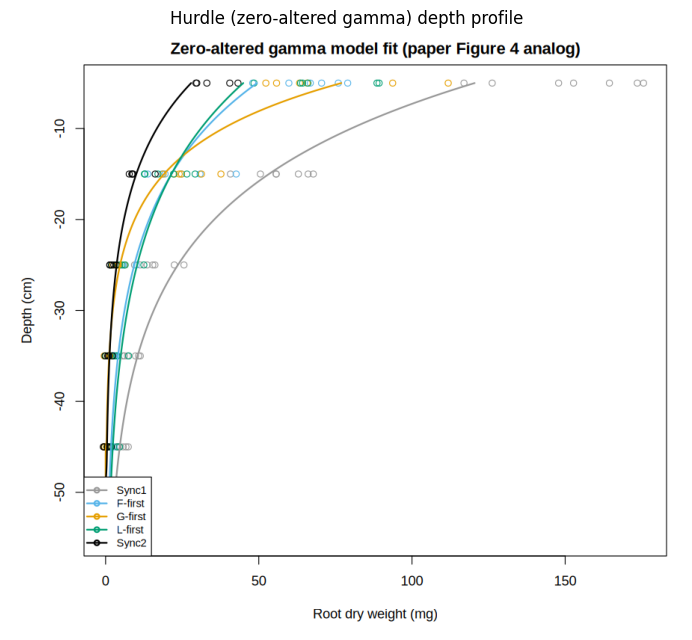

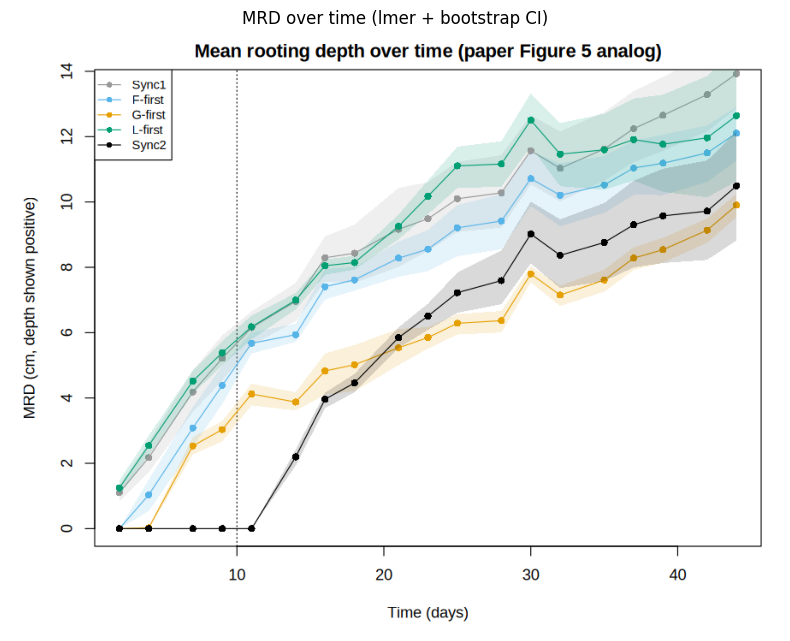

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for name, title in [("fig4_hurdle_analog.png", "Hurdle (zero-altered gamma) depth profile"),
                    ("fig5_mrd_analog.png", "MRD over time (lmer + bootstrap CI)")]:
    fig, ax = plt.subplots(figsize=(8, 6.5))
    ax.imshow(mpimg.imread("/content/out/" + name))
    ax.axis("off"); ax.set_title(title)
    fig.tight_layout(); fig.savefig("display_" + name, dpi=110); plt.show()

## Interpretation

- **Depth profile:** the hurdle fit separates the probability that a layer contains roots (binomial part) from the root mass given presence (gamma part); the merged curve `Pi·μ` is the paper's Figure 4 pattern — root mass decays with depth, and treatment differences in deep layers reflect arrival order.
- **MRD dynamics:** `results.csv` stores MRD as negative cm, so model slopes are negative (deepening). From the executed `lmer`: baseline deepening `dafs` = −0.273 cm/day (≈2.7 mm/day) and `TreatmentG-first:dafs` = +0.064 cm/day, i.e. grasses-first communities deepen at ≈2.09 mm/day — a ≈24% slower progression, matching the paper's Results (2.1 vs 2.7 mm/day). Sync2 lags by its 10-day delayed sowing (`dafs` shift, zeroed before day 9).
- The figures are generated here from the shared data; they are this notebook's reproduction, not the paper's published figures.

- ハードルモデルの合成曲線 `Pi·μ` が論文 Figure 4 のパターンを再現します。
- `results.csv` の MRD は負の値のため、`lmer` の傾きは負（深さ方向）。実行結果は `dafs` = −0.273 cm/day（≈2.7 mm/day）、`TreatmentG-first:dafs` = +0.064 cm/day、すなわち grasses-first の進行は ≈2.09 mm/day で論文の「2.1 vs 2.7 mm/day、24% 遅い」と一致します。Sync2 は 10 日遅れ播種分だけ遅れます。

### Export

Small CSV exports of the model fixed effects and the treatment×time MRD means are saved under `/content/out/`.

モデル係数と処理×日ごとの MRD 平均を CSV に保存します。

In [ ]:
import pandas as pd

fe = pd.read_csv("/content/out/lmer_fixed_effects.csv")
mm = pd.read_csv("/content/out/mrd_treatment_means.csv")
print("lmer fixed effects:"); print(fe.to_string(index=False))
print("\nMRD treatment means (last rows):"); print(mm.tail(8).to_string(index=False))
fe.to_csv("lmer_fixed_effects_export.csv", index=False)

lmer fixed effects:
                 term  estimate
          (Intercept) -2.552457
     TreatmentF-first  0.726108
     TreatmentG-first  1.787876
     TreatmentL-first -0.554639
       TreatmentSync2  0.547890
                 dafs -0.273198
TreatmentF-first:dafs  0.014196
TreatmentG-first:dafs  0.064130
TreatmentL-first:dafs  0.022438
  TreatmentSync2:dafs -0.002119

MRD treatment means (last rows):
Treatment  Time  meanValue     lower    upper
    Sync2    28   7.593733  8.518941 6.871838
    Sync2    30   9.019605 10.009954 8.119223
    Sync2    32   8.367936  9.468112 7.361953
    Sync2    35   8.759826  9.964989 7.575243
    Sync2    37   9.302176 10.649970 7.999191
    Sync2    39   9.574374 11.017045 8.131703
    Sync2    42   9.720664 11.269926 8.228710
    Sync2    44  10.492867 12.164318 8.822645
